Project done by Ajay Vardhan <END>

INDIAN INSTITUTE OF TECHNOLOGY BHUBANSWER <END>



22CS02013 <end>

ajayvardhannaik@gmail.com

In [6]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices("GPU"))

2.20.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
import tensorflow as tf
import os
import zipfile

print("TensorFlow version:", tf.__version__)

from google.colab import drive
drive.mount('/content/drive')

TensorFlow version: 2.20.0
Mounted at /content/drive


In [8]:
zip_path = "/content/drive/MyDrive/brain tumor dataset.zip"

print("File exists:", os.path.exists(zip_path))

File exists: True


In [9]:
extract_path = "/content/brain_tumor_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


# **Exploratory Data Analytics**

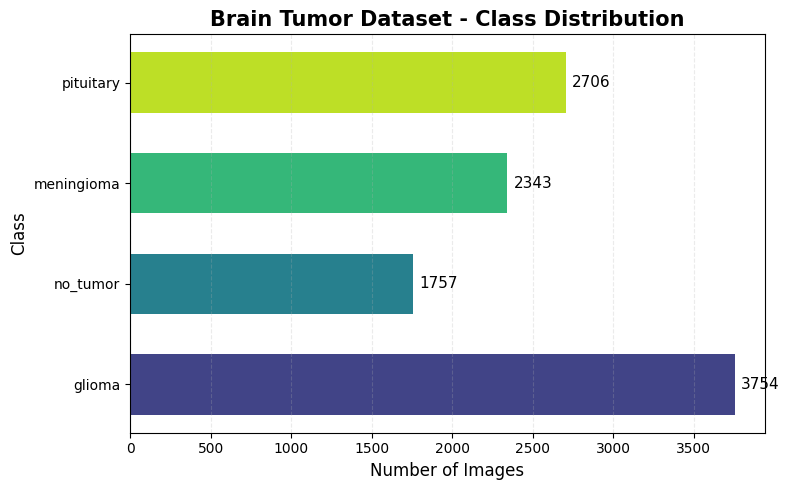

In [10]:
import os
import matplotlib.pyplot as plt
import numpy as np

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

class_names = []
image_counts = []

for root, dirs, files in os.walk(extract_path):

    image_count = sum(
        1 for file in files
        if file.lower().endswith(image_extensions)
    )

    if image_count > 0:
        class_names.append(os.path.basename(root))
        image_counts.append(image_count)


# Create gradient colors
colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(class_names))
)

# Create horizontal bar graph
plt.figure(figsize=(8, 5))

bars = plt.barh(
    class_names,
    image_counts,
    color=colors,
    edgecolor="none",
    height=0.6
)

# Add image count at the end of each bar
for bar, count in zip(bars, image_counts):
    plt.text(
        bar.get_width() + max(image_counts) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center",
        fontsize=11
    )

plt.xlabel("Number of Images", fontsize=12)
plt.ylabel("Class", fontsize=12)
plt.title(
    "Brain Tumor Dataset - Class Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

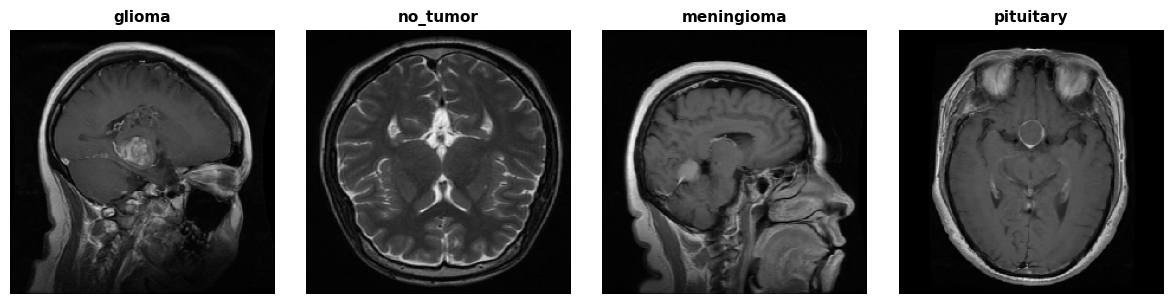

In [11]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

# Find class folders
class_data = []

for root, dirs, files in os.walk(extract_path):

    image_files = [
        file for file in files
        if file.lower().endswith(image_extensions)
    ]

    if len(image_files) > 0:
        class_data.append((os.path.basename(root), root, image_files[0]))

# Create one row with all classes
fig, axes = plt.subplots(
    1,
    len(class_data),
    figsize=(12, 3)
)

for i, (class_name, folder, image_file) in enumerate(class_data):

    image_path = os.path.join(folder, image_file)

    # Same size for all images
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)

    axes[i].imshow(image_array.astype("uint8"))
    axes[i].set_title(class_name, fontsize=11, fontweight="bold")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

 ## 1. Checking image dimensions

In [12]:
import os
from PIL import Image
from collections import Counter

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

image_sizes = []

for root, dirs, files in os.walk(extract_path):

    for file in files:

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(root, file)

            try:
                with Image.open(image_path) as img:
                    width, height = img.size
                    image_sizes.append((height, width))

            except:
                pass


# Calculate statistics
heights = [h for h, w in image_sizes]
widths = [w for h, w in image_sizes]

dimension_counts = Counter(image_sizes)

print("=" * 50)
print("       BRAIN TUMOR DATASET - IMAGE DIMENSIONS")
print("=" * 50)

print(f"\nTotal Images        : {len(image_sizes):,}")

print("\n" + "-" * 50)
print("DIMENSION RANGE")
print("-" * 50)

print(f"Minimum Height     : {min(heights)} px")
print(f"Maximum Height     : {max(heights)} px")
print(f"Minimum Width      : {min(widths)} px")
print(f"Maximum Width      : {max(widths)} px")

print("\n" + "-" * 50)
print("TOP 10 MOST COMMON IMAGE DIMENSIONS")
print("-" * 50)

for rank, ((height, width), count) in enumerate(
    dimension_counts.most_common(10), 1
):
    percentage = (count / len(image_sizes)) * 100

    print(
        f"{rank:>2}. "
        f"{height:>4} × {width:<4} "
        f"--- {count:>5,} images "
        f"({percentage:>5.2f}%)"
    )

print("\n" + "=" * 50)

       BRAIN TUMOR DATASET - IMAGE DIMENSIONS

Total Images        : 10,560

--------------------------------------------------
DIMENSION RANGE
--------------------------------------------------
Minimum Height     : 167 px
Maximum Height     : 1446 px
Minimum Width      : 150 px
Maximum Width      : 1920 px

--------------------------------------------------
TOP 10 MOST COMMON IMAGE DIMENSIONS
--------------------------------------------------
 1.  512 × 512  --- 8,413 images (79.67%)
 2.  225 × 225  ---   325 images ( 3.08%)
 3.  630 × 630  ---    82 images ( 0.78%)
 4.  251 × 201  ---    53 images ( 0.50%)
 5.  221 × 228  ---    50 images ( 0.47%)
 6.  168 × 300  ---    49 images ( 0.46%)
 7.  217 × 232  ---    49 images ( 0.46%)
 8.  256 × 256  ---    47 images ( 0.45%)
 9.  236 × 236  ---    44 images ( 0.42%)
10.  442 × 442  ---    44 images ( 0.42%)



## 2. Checking for corrupted images


In [13]:
import os
from PIL import Image

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

total_images = 0
corrupted_images = []

for root, dirs, files in os.walk(extract_path):

    for file in files:

        if file.lower().endswith(image_extensions):

            total_images += 1
            image_path = os.path.join(root, file)

            try:
                with Image.open(image_path) as img:
                    img.verify()

            except Exception:
                corrupted_images.append(image_path)


print("=" * 50)
print("       CORRUPTED IMAGE CHECK")
print("=" * 50)

print(f"\nTotal Images      : {total_images:,}")
print(f"Corrupted Images  : {len(corrupted_images):,}")
print(f"Valid Images      : {total_images - len(corrupted_images):,}")

if len(corrupted_images) == 0:
    print("\n✓ No corrupted images found.")
else:
    print("\nCorrupted image files:")
    for image in corrupted_images:
        print(image)

print("\n" + "=" * 50)

       CORRUPTED IMAGE CHECK

Total Images      : 10,560
Corrupted Images  : 0
Valid Images      : 10,560

✓ No corrupted images found.



## 3. Checking duplicate images

In [14]:
import os
import hashlib
from collections import defaultdict

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

image_hashes = defaultdict(list)

for root, dirs, files in os.walk(extract_path):

    for file in files:

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(root, file)

            try:
                with open(image_path, "rb") as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()

                image_hashes[file_hash].append(image_path)

            except Exception:
                pass


# Find duplicate groups
duplicate_groups = {
    hash_value: paths
    for hash_value, paths in image_hashes.items()
    if len(paths) > 1
}

duplicate_image_count = sum(
    len(paths) - 1
    for paths in duplicate_groups.values()
)

print("=" * 50)
print("          DUPLICATE IMAGE CHECK")
print("=" * 50)

print(f"\nTotal Images       : {total_images:,}")
print(f"Unique Images      : {len(image_hashes):,}")
print(f"Duplicate Groups   : {len(duplicate_groups):,}")
print(f"Duplicate Images   : {duplicate_image_count:,}")

if len(duplicate_groups) == 0:
    print("\n✓ No exact duplicate images found.")
else:
    print("\n⚠ Exact duplicate images found.")

print("\n" + "=" * 50)

          DUPLICATE IMAGE CHECK

Total Images       : 10,560
Unique Images      : 10,560
Duplicate Groups   : 0
Duplicate Images   : 0

✓ No exact duplicate images found.



## 4. checking color of images

IMAGE COLOR MODE DISTRIBUTION
L      --- 3,099 images (29.3%)
RGB    --- 4,392 images (41.6%)
RGBA   --- 3,068 images (29.1%)
P      --- 1 images (0.0%)


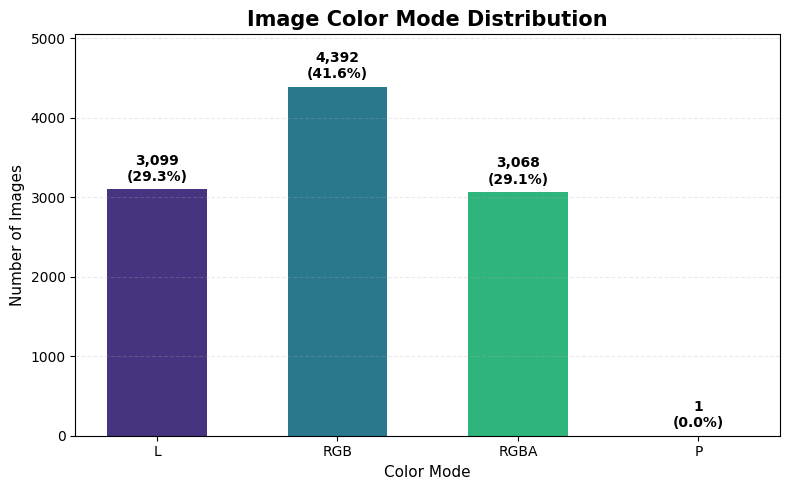

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

image_modes = Counter()
total_images = 0

# -----------------------------------------
# Count image color modes
# -----------------------------------------

for root, dirs, files in os.walk(extract_path):

    for file in files:

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(root, file)

            try:
                with Image.open(image_path) as img:

                    image_modes[img.mode] += 1
                    total_images += 1

            except:
                pass


# -----------------------------------------
# Display results
# -----------------------------------------

print("=" * 50)
print("IMAGE COLOR MODE DISTRIBUTION")
print("=" * 50)

for mode, count in image_modes.items():

    percentage = (count / total_images) * 100

    print(
        f"{mode:<6} --- "
        f"{count:,} images "
        f"({percentage:.1f}%)"
    )

print("=" * 50)


# -----------------------------------------
# Gradient Bar Graph
# -----------------------------------------

modes = list(image_modes.keys())
counts = list(image_modes.values())

colors = plt.cm.viridis(
    np.linspace(0.15, 0.9, len(modes))
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    modes,
    counts,
    width=0.55,
    color=colors,
    edgecolor="none"
)

plt.title(
    "Image Color Mode Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Color Mode",
    fontsize=11
)

plt.ylabel(
    "Number of Images",
    fontsize=11
)

# Add count + percentage
for bar, count in zip(bars, counts):

    percentage = (count / total_images) * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(counts) * 0.015,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.ylim(
    0,
    max(counts) * 1.15
)

plt.tight_layout()
plt.show()

       PIXEL INTENSITY ANALYSIS

Minimum Intensity : 0
Maximum Intensity : 255
Mean Intensity    : 48.96
Median Intensity  : 39.00



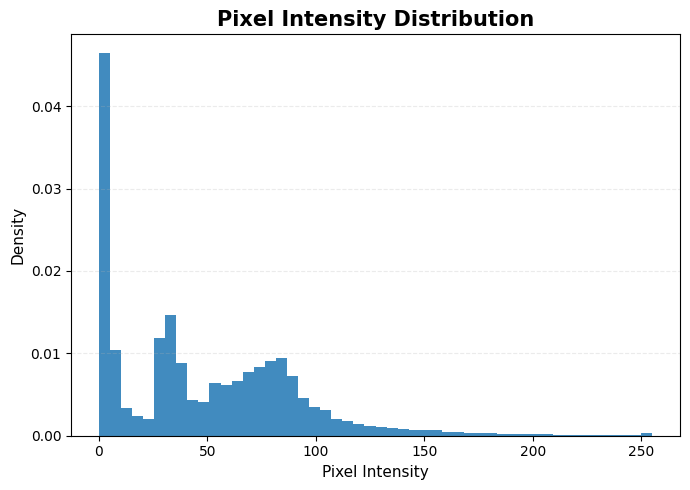

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

pixel_values = []

for root, dirs, files in os.walk(extract_path):

    for file in files:

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(root, file)

            try:
                with Image.open(image_path) as img:

                    # Convert all images to grayscale
                    img = img.convert("L")

                    pixels = np.array(img).flatten()

                    # Sample pixels to reduce memory usage
                    pixel_values.extend(pixels[::10])

            except:
                pass


pixel_values = np.array(pixel_values)

print("=" * 50)
print("       PIXEL INTENSITY ANALYSIS")
print("=" * 50)

print(f"\nMinimum Intensity : {pixel_values.min()}")
print(f"Maximum Intensity : {pixel_values.max()}")
print(f"Mean Intensity    : {pixel_values.mean():.2f}")
print(f"Median Intensity  : {np.median(pixel_values):.2f}")

print("\n" + "=" * 50)


# -----------------------------
# Plot distribution
# -----------------------------

plt.figure(figsize=(7, 5))

plt.hist(
    pixel_values,
    bins=50,
    density=True,
    alpha=0.85
)

plt.title(
    "Pixel Intensity Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Pixel Intensity", fontsize=11)
plt.ylabel("Density", fontsize=11)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

##  Class-wise Pixel Statistics

              CLASS-WISE PIXEL STATISTICS
     Class  Mean Median   Std Minimum Maximum
    glioma 42.72  34.00 37.98       0     255
meningioma 48.04  36.00 44.63       0     255
  no_tumor 58.43  30.00 64.60       0     255
 pituitary 55.57  58.00 39.55       0     255


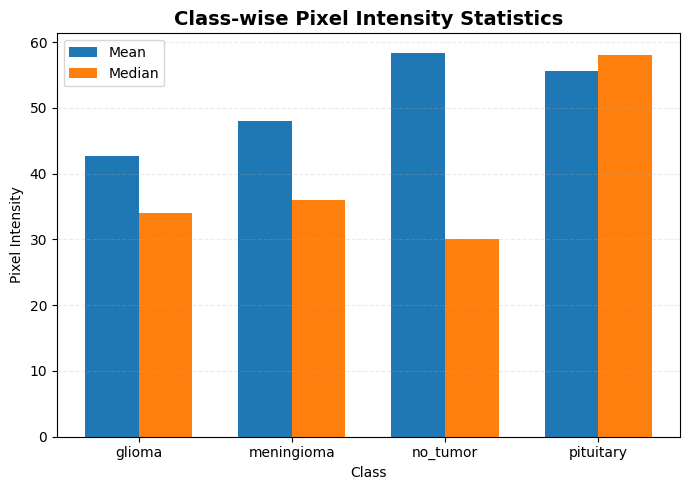

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

class_pixels = {}

# Collect pixel values class-wise
for root, dirs, files in os.walk(extract_path):

    image_files = [
        file for file in files
        if file.lower().endswith(image_extensions)
    ]

    if len(image_files) == 0:
        continue

    class_name = os.path.basename(root)
    pixels = []

    for file in image_files:

        image_path = os.path.join(root, file)

        try:
            with Image.open(image_path) as img:

                # Convert all images to grayscale
                img = img.convert("L")

                pixel_array = np.array(img).flatten()

                # Sample pixels to reduce memory usage
                pixels.extend(pixel_array[::10])

        except:
            pass

    class_pixels[class_name] = np.array(pixels)


# -----------------------------------
# Calculate class-wise statistics
# -----------------------------------

statistics = []

for class_name, pixels in class_pixels.items():

    statistics.append({
        "Class": class_name,
        "Mean": np.mean(pixels),
        "Median": np.median(pixels),
        "Std": np.std(pixels),
        "Minimum": np.min(pixels),
        "Maximum": np.max(pixels)
    })


df_stats = pd.DataFrame(statistics)

# Sort by class name
df_stats = df_stats.sort_values("Class").reset_index(drop=True)


# -----------------------------------
# Display results
# -----------------------------------

print("=" * 75)
print("              CLASS-WISE PIXEL STATISTICS")
print("=" * 75)

print(
    df_stats.to_string(
        index=False,
        formatters={
            "Mean": "{:.2f}".format,
            "Median": "{:.2f}".format,
            "Std": "{:.2f}".format,
            "Minimum": "{:.0f}".format,
            "Maximum": "{:.0f}".format
        }
    )
)

print("=" * 75)


# -----------------------------------
# Mean & Median comparison
# -----------------------------------

plt.figure(figsize=(7, 5))

x = np.arange(len(df_stats))
width = 0.35

plt.bar(
    x - width / 2,
    df_stats["Mean"],
    width,
    label="Mean"
)

plt.bar(
    x + width / 2,
    df_stats["Median"],
    width,
    label="Median"
)

plt.xticks(
    x,
    df_stats["Class"]
)

plt.xlabel("Class")
plt.ylabel("Pixel Intensity")
plt.title(
    "Class-wise Pixel Intensity Statistics",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

# **Data PreProcessing**

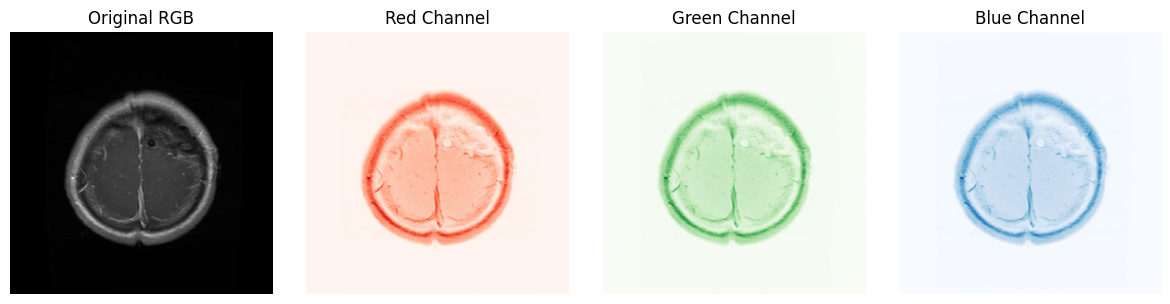

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

# Find first RGB/RGBA image
sample_path = None

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            path = os.path.join(root, file)

            try:
                with Image.open(path) as img:
                    if img.mode in ["RGB", "RGBA"]:
                        sample_path = path
                        break
            except:
                pass

    if sample_path:
        break


# Load as RGB
img = Image.open(sample_path).convert("RGB")
img_array = np.array(img)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(img_array)
axes[0].set_title("Original RGB")

axes[1].imshow(img_array[:, :, 0], cmap="Reds")
axes[1].set_title("Red Channel")

axes[2].imshow(img_array[:, :, 1], cmap="Greens")
axes[2].set_title("Green Channel")

axes[3].imshow(img_array[:, :, 2], cmap="Blues")
axes[3].set_title("Blue Channel")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 1. Convert to grayscale

In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

def convert_to_grayscale(image_path):

    # Read image
    image = tf.io.read_file(image_path)

    # Decode as RGB
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # RGB → Grayscale
    image = tf.image.rgb_to_grayscale(image)

    return image

## 2. Resize to 224 × 224

In [20]:
def resize_image(image):

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    return image

## 3. Normalize the pixels

In [21]:
def normalize_image(image):

    image = tf.cast(
        image,
        tf.float32
    )

    image = image / 255.0

    return image

## 4. Applying  data preprocessing

          IMAGE PREPROCESSING VERIFICATION

Total Images Processed : 10,560
Successfully Processed : 10,560
Failed Images          : 0

Preprocessing Applied:
  1. RGB / RGBA / L / P → Grayscale
  2. Resize → 224 × 224
  3. Normalize → [0, 1]
  4. Final Shape → 224 × 224 × 1



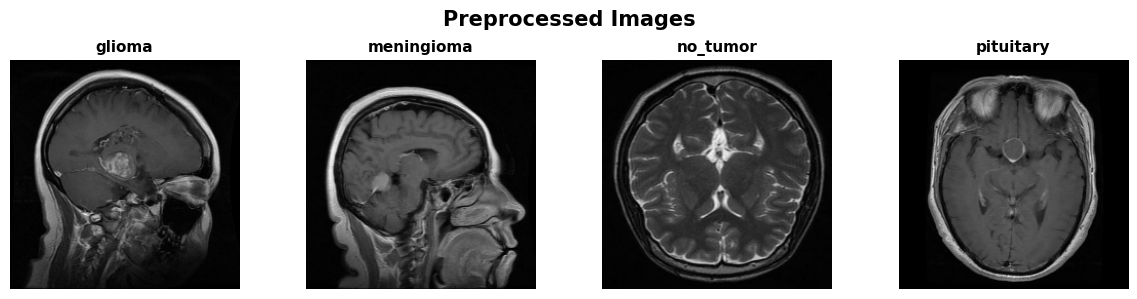

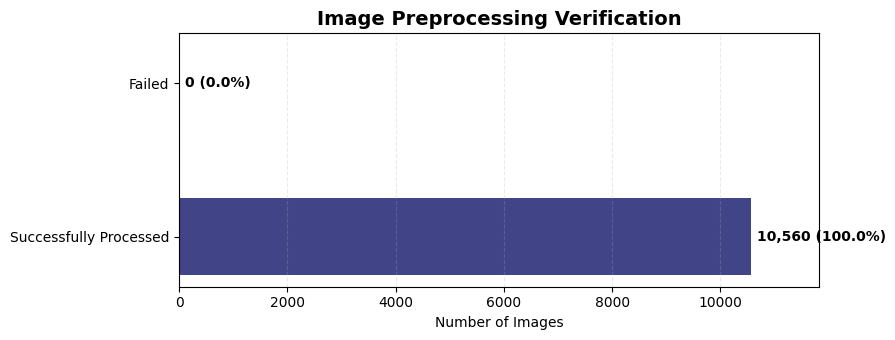


✓ ALL IMAGES SUCCESSFULLY PREPROCESSED
✓ Grayscale conversion completed
✓ Resize completed: 224 × 224
✓ Normalization completed: [0, 1]
✓ No preprocessing failures


In [22]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

IMG_SIZE = (224, 224)

# --------------------------------------------------
# 1. PREPROCESS ALL IMAGES
# --------------------------------------------------

total_images = 0
processed_images = 0
failed_images = 0

# Store one processed image from each class
class_images = {}

for root, dirs, files in os.walk(extract_path):

    image_files = [
        file for file in files
        if file.lower().endswith(image_extensions)
    ]

    for file in image_files:

        image_path = os.path.join(root, file)

        try:
            # --------------------------------------
            # Read image
            # --------------------------------------
            image = tf.io.read_file(image_path)

            # --------------------------------------
            # Decode image
            # RGB / RGBA / L / P → RGB
            # --------------------------------------
            image = tf.image.decode_image(
                image,
                channels=3,
                expand_animations=False
            )

            # --------------------------------------
            # 1. Convert RGB → Grayscale
            # --------------------------------------
            image = tf.image.rgb_to_grayscale(image)

            # --------------------------------------
            # 2. Resize → 224 × 224
            # --------------------------------------
            image = tf.image.resize(
                image,
                IMG_SIZE
            )

            # --------------------------------------
            # 3. Normalize → [0, 1]
            # --------------------------------------
            image = tf.cast(
                image,
                tf.float32
            ) / 255.0

            total_images += 1

            # --------------------------------------
            # Confirm shape = 224 × 224 × 1
            # --------------------------------------
            if image.shape == (224, 224, 1):
                processed_images += 1
            else:
                failed_images += 1

            # --------------------------------------
            # Store 1 image from each class
            # --------------------------------------
            class_name = os.path.basename(root)

            if class_name not in class_images:
                class_images[class_name] = image

        except Exception:
            failed_images += 1


# --------------------------------------------------
# 2. PRINT PREPROCESSING RESULTS
# --------------------------------------------------

print("=" * 60)
print("          IMAGE PREPROCESSING VERIFICATION")
print("=" * 60)

print(f"\nTotal Images Processed : {total_images:,}")
print(f"Successfully Processed : {processed_images:,}")
print(f"Failed Images          : {failed_images:,}")

print("\nPreprocessing Applied:")
print("  1. RGB / RGBA / L / P → Grayscale")
print("  2. Resize → 224 × 224")
print("  3. Normalize → [0, 1]")
print("  4. Final Shape → 224 × 224 × 1")

print("\n" + "=" * 60)


# --------------------------------------------------
# 3. DISPLAY ONE IMAGE FROM EACH CLASS
# --------------------------------------------------

class_names = sorted(class_images.keys())

plt.figure(figsize=(12, 3))

for i, class_name in enumerate(class_names):

    image = class_images[class_name]

    plt.subplot(1, len(class_names), i + 1)

    plt.imshow(
        image.numpy().squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        class_name,
        fontsize=11,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle(
    "Preprocessed Images",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 4. HORIZONTAL BAR GRAPH
# --------------------------------------------------

labels = [
    "Successfully Processed",
    "Failed"
]

values = [
    processed_images,
    failed_images
]

# Gradient colors
colors = plt.cm.viridis(
    np.linspace(0.2, 0.8, len(labels))
)

plt.figure(figsize=(9, 3.5))

bars = plt.barh(
    labels,
    values,
    color=colors,
    height=0.5
)

plt.title(
    "Image Preprocessing Verification",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Images")

# Add values
for bar, value in zip(bars, values):

    percentage = (
        value / total_images * 100
        if total_images > 0 else 0
    )

    plt.text(
        bar.get_width() + total_images * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,} ({percentage:.1f}%)",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.xlim(
    0,
    total_images * 1.12
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 5. FINAL CONFIRMATION
# --------------------------------------------------

if processed_images == total_images and failed_images == 0:

    print("\n✓ ALL IMAGES SUCCESSFULLY PREPROCESSED")
    print("✓ Grayscale conversion completed")
    print("✓ Resize completed: 224 × 224")
    print("✓ Normalization completed: [0, 1]")
    print("✓ No preprocessing failures")

else:

    print("\n⚠ SOME IMAGES FAILED DURING PREPROCESSING")

## Class-wise pixel intensity statistic

       CLASS-WISE PIXEL INTENSITY STATISTICS

GLIOMA
Mean       : 0.1669
Median     : 0.1300
Std        : 0.1489
Minimum    : 0.0000
Maximum    : 1.0000

NO_TUMOR
Mean       : 0.2371
Median     : 0.1459
Std        : 0.2540
Minimum    : 0.0000
Maximum    : 1.0000

MENINGIOMA
Mean       : 0.1924
Median     : 0.1379
Std        : 0.1806
Minimum    : 0.0000
Maximum    : 1.0000

PITUITARY
Mean       : 0.2155
Median     : 0.2242
Std        : 0.1528
Minimum    : 0.0000
Maximum    : 1.0000



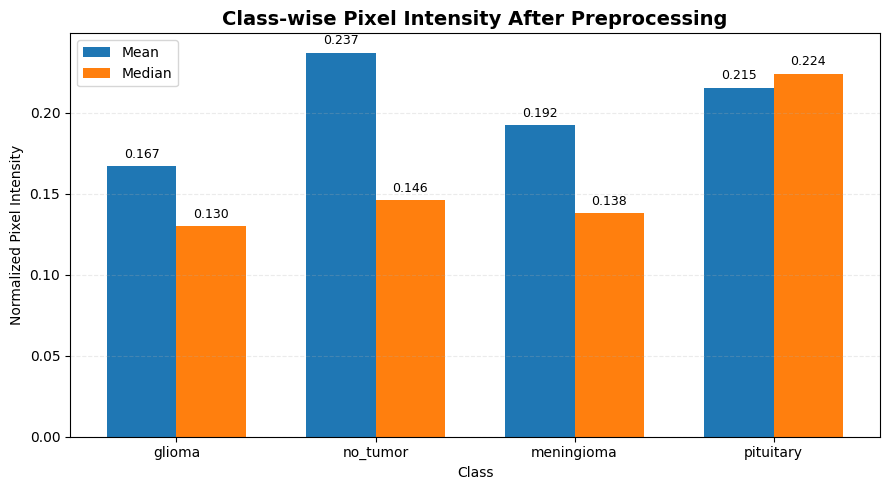

In [23]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

class_pixel_values = {}

for root, dirs, files in os.walk(extract_path):

    image_files = [
        file for file in files
        if file.lower().endswith(image_extensions)
    ]

    if len(image_files) == 0:
        continue

    class_name = os.path.basename(root)
    pixels = []

    for file in image_files:

        image_path = os.path.join(root, file)

        try:
            # 1. Grayscale
            image = convert_to_grayscale(image_path)

            # 2. Resize
            image = resize_image(image)

            # 3. Normalize
            image = normalize_image(image)

            # Collect pixel values
            pixels.extend(
                image.numpy().flatten()[::10]
            )

        except:
            pass

    class_pixel_values[class_name] = np.array(pixels)


# ------------------------------------------------
# Print class-wise statistics
# ------------------------------------------------

print("=" * 65)
print("       CLASS-WISE PIXEL INTENSITY STATISTICS")
print("=" * 65)

for class_name, pixels in class_pixel_values.items():

    print(
        f"\n{class_name.upper()}"
    )

    print(f"Mean       : {np.mean(pixels):.4f}")
    print(f"Median     : {np.median(pixels):.4f}")
    print(f"Std        : {np.std(pixels):.4f}")
    print(f"Minimum    : {np.min(pixels):.4f}")
    print(f"Maximum    : {np.max(pixels):.4f}")

print("\n" + "=" * 65)


# ------------------------------------------------
# Plot class-wise mean and median
# ------------------------------------------------

class_names = list(class_pixel_values.keys())

means = [
    np.mean(class_pixel_values[c])
    for c in class_names
]

medians = [
    np.median(class_pixel_values[c])
    for c in class_names
]

x = np.arange(len(class_names))
width = 0.35

plt.figure(figsize=(9, 5))

bars1 = plt.bar(
    x - width / 2,
    means,
    width,
    label="Mean"
)

bars2 = plt.bar(
    x + width / 2,
    medians,
    width,
    label="Median"
)

plt.xticks(x, class_names)
plt.ylabel("Normalized Pixel Intensity")
plt.xlabel("Class")

plt.title(
    "Class-wise Pixel Intensity After Preprocessing",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Add values
for bars in [bars1, bars2]:

    for bar in bars:

        value = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.005,
            f"{value:.3f}",
            ha="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

# **Train/validation/test split**

## Collect image paths and class labels

In [24]:
import os

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

image_paths = []
labels = []

# Get class names
class_names = sorted([
    folder
    for folder in os.listdir(extract_path)
    if os.path.isdir(os.path.join(extract_path, folder))
])

# Assign numerical labels
class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

print("Classes:")
for class_name, index in class_to_index.items():
    print(index, "---", class_name)


# Collect image paths and labels
for class_name in class_names:

    class_path = os.path.join(
        extract_path,
        class_name
    )

    for root, dirs, files in os.walk(class_path):

        for file in files:

            if file.lower().endswith(image_extensions):

                image_paths.append(
                    os.path.join(root, file)
                )

                labels.append(
                    class_to_index[class_name]
                )


print("\nTotal Images:", len(image_paths))

Classes:
0 --- glioma
1 --- meningioma
2 --- no_tumor
3 --- pituitary

Total Images: 10560


## Stratified Train / Validation / Test split

In [25]:
from sklearn.model_selection import train_test_split

# -----------------------------------------
# 70% Train + 30% Temporary
# -----------------------------------------

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)


# -----------------------------------------
# 15% Validation + 15% Test
# -----------------------------------------

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)


# -----------------------------------------
# Display split sizes
# -----------------------------------------

print("=" * 50)
print("        DATASET SPLIT")
print("=" * 50)

print(f"\nTotal      : {len(image_paths):,}")
print(f"Train      : {len(train_paths):,}")
print(f"Validation : {len(val_paths):,}")
print(f"Test       : {len(test_paths):,}")

print("\n" + "=" * 50)

        DATASET SPLIT

Total      : 10,560
Train      : 7,392
Validation : 1,584
Test       : 1,584



## Verify class distribution

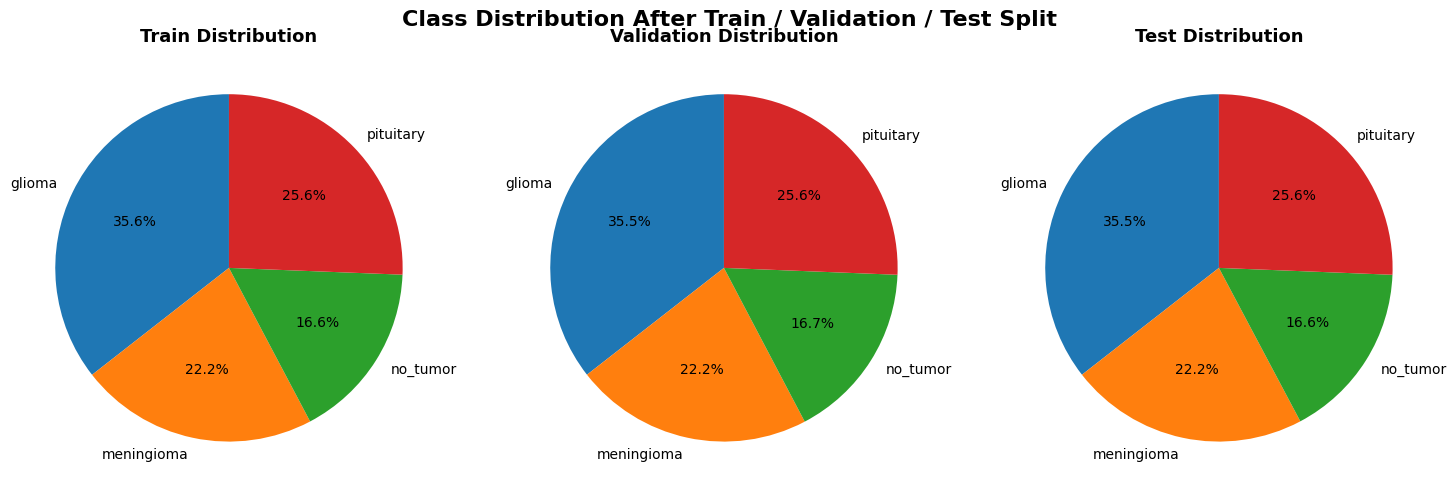

In [26]:
from collections import Counter
import matplotlib.pyplot as plt

splits = {
    "Train": train_labels,
    "Validation": val_labels,
    "Test": test_labels
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

for ax, (split_name, split_labels) in zip(axes, splits.items()):

    counts = Counter(split_labels)

    values = [
        counts[class_to_index[class_name]]
        for class_name in class_names
    ]

    ax.pie(
        values,
        labels=class_names,
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 10}
    )

    ax.set_title(
        f"{split_name} Distribution",
        fontsize=13,
        fontweight="bold"
    )

plt.suptitle(
    "Class Distribution After Train / Validation / Test Split",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# **Data augmentation layers**

In [27]:
import tensorflow as tf

# ============================================================
# DATA AUGMENTATION LAYER
# ============================================================

data_augmentation = tf.keras.Sequential([

    # Random horizontal flip
    tf.keras.layers.RandomFlip(
        mode="horizontal"
    ),

    # Random rotation ±5%
    tf.keras.layers.RandomRotation(
        factor=0.05
    ),

    # Random zoom ±10%
    tf.keras.layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

    # Random translation ±5%
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )

], name="data_augmentation")

print("✓ Data augmentation layer created successfully")

✓ Data augmentation layer created successfully


In [28]:
import numpy as np
import tensorflow as tf
from collections import Counter

BATCH_SIZE = 32

# ============================================================
# REQUIRED AUGMENTED SAMPLES PER CLASS
# ============================================================

AUGMENTED_TARGETS = {
    class_to_index["glioma"]: 0,
    class_to_index["meningioma"]: 660,
    class_to_index["no_tumor"]: 1070,
    class_to_index["pituitary"]: 406
}


# ============================================================
# ORIGINAL TRAINING DATA
# ============================================================

train_paths_array = np.array(train_paths)
train_labels_array = np.array(train_labels)

real_paths = train_paths_array.copy()
real_labels = train_labels_array.copy()


# ============================================================
# SELECT IMAGES FOR DYNAMIC AUGMENTATION
# ============================================================

rng = np.random.default_rng(42)

augmented_paths = []
augmented_labels = []

for class_name, class_index in class_to_index.items():

    # Get paths belonging to this class
    class_indices = np.where(
        train_labels_array == class_index
    )[0]

    class_paths = train_paths_array[class_indices]

    # Exact number requested for this class
    n_augmented = AUGMENTED_TARGETS[class_index]

    if n_augmented > 0:

        selected_paths = rng.choice(
            class_paths,
            size=n_augmented,
            replace=True
        )

        augmented_paths.extend(
            selected_paths.tolist()
        )

        augmented_labels.extend(
            [class_index] * n_augmented
        )


augmented_paths = np.array(augmented_paths)
augmented_labels = np.array(augmented_labels)


# ============================================================
# REAL IMAGE PREPROCESSING
# ============================================================

def preprocess_real(image_path, label):

    # Grayscale
    image = convert_to_grayscale(image_path)

    # Resize
    image = resize_image(image)

    # Normalize [0,1]
    image = normalize_image(image)

    # 1 channel → 3 channels for VGG16
    image = tf.repeat(
        image,
        repeats=3,
        axis=-1
    )

    return image, label


# ============================================================
# DYNAMIC AUGMENTATION
# ============================================================

def preprocess_dynamic_augmented(image_path, label):

    # Grayscale
    image = convert_to_grayscale(image_path)

    # Resize
    image = resize_image(image)

    # Normalize [0,1]
    image = normalize_image(image)

    # 1 channel → 3 channels
    image = tf.repeat(
        image,
        repeats=3,
        axis=-1
    )

    # Dynamic augmentation
    image = data_augmentation(
        image,
        training=True
    )

    return image, label


# ============================================================
# REAL DATASET
# ============================================================

real_train_ds = tf.data.Dataset.from_tensor_slices(
    (
        real_paths,
        real_labels
    )
)

real_train_ds = real_train_ds.map(
    preprocess_real,
    num_parallel_calls=tf.data.AUTOTUNE
)


# ============================================================
# DYNAMIC AUGMENTED DATASET
# ============================================================

augmented_train_ds = tf.data.Dataset.from_tensor_slices(
    (
        augmented_paths,
        augmented_labels
    )
)

augmented_train_ds = augmented_train_ds.map(
    preprocess_dynamic_augmented,
    num_parallel_calls=tf.data.AUTOTUNE
)


# ============================================================
# COMBINE REAL + AUGMENTED
# ============================================================

vgg_train_ds = real_train_ds.concatenate(
    augmented_train_ds
)

vgg_train_ds = vgg_train_ds.shuffle(
    buffer_size=len(real_paths) + len(augmented_paths),
    seed=42
)

vgg_train_ds = vgg_train_ds.batch(
    BATCH_SIZE
)

vgg_train_ds = vgg_train_ds.prefetch(
    tf.data.AUTOTUNE
)


# ============================================================
# VERIFICATION
# ============================================================

real_counts = Counter(real_labels)
aug_counts = Counter(augmented_labels)

print("=" * 70)
print("        FINAL VGG16 TRAINING DATA DISTRIBUTION")
print("=" * 70)

for class_name, class_index in class_to_index.items():

    real_count = real_counts[class_index]
    aug_count = aug_counts[class_index]
    total_count = real_count + aug_count

    print(
        f"{class_name:<15} : "
        f"{real_count:,} real + "
        f"{aug_count:,} augmented = "
        f"{total_count:,}"
    )

print("-" * 70)

print(
    f"Total Real Images       : {len(real_paths):,}"
)

print(
    f"Total Augmented Images  : {len(augmented_paths):,}"
)

print(
    f"Total Training Samples  : "
    f"{len(real_paths) + len(augmented_paths):,}"
)

print("=" * 70)


# ============================================================
# SHAPE VERIFICATION
# ============================================================

for images, labels in vgg_train_ds.take(1):

    print("\nDATASET VERIFICATION")
    print("-" * 40)

    print("Batch shape :", images.shape)
    print(
        "Pixel range:",
        tf.reduce_min(images).numpy(),
        "to",
        tf.reduce_max(images).numpy()
    )

    print("-" * 40)

        FINAL VGG16 TRAINING DATA DISTRIBUTION
glioma          : 2,628 real + 0 augmented = 2,628
meningioma      : 1,640 real + 660 augmented = 2,300
no_tumor        : 1,230 real + 1,070 augmented = 2,300
pituitary       : 1,894 real + 406 augmented = 2,300
----------------------------------------------------------------------
Total Real Images       : 7,392
Total Augmented Images  : 2,136
Total Training Samples  : 9,528

DATASET VERIFICATION
----------------------------------------
Batch shape : (32, 224, 224, 3)
Pixel range: 0.0 to 1.0
----------------------------------------


# **VGG-16 Model**

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16

IMG_SIZE = (224, 224)
NUM_CLASSES = 4

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Do NOT freeze VGG16
base_model.trainable = True

print("Total VGG16 layers:", len(base_model.layers))
print("Trainable layers:", sum(
    layer.trainable for layer in base_model.layers
))

Total VGG16 layers: 19
Trainable layers: 19


In [30]:
inputs = layers.Input(
    shape=(224, 224, 3)
)

x = base_model(inputs)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.5)(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

vgg16_model = Model(
    inputs=inputs,
    outputs=outputs
)

vgg16_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,964 (56.77 MB)

 Trainable params: 14,880,196 (56.76 MB)

 Non-trainable params: 768 (3.00 KB)

In [31]:
vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
callbacks_vgg = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [34]:
# ============================================
# VGG16 VALIDATION DATASET
# ============================================

def preprocess_vgg16_validation(image_path, label):

    # Grayscale
    image = convert_to_grayscale(image_path)

    # Resize
    image = resize_image(image)

    # Normalize
    image = normalize_image(image)

    # 1 channel → 3 channels
    image = tf.repeat(
        image,
        repeats=3,
        axis=-1
    )

    return image, label


vgg_val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

vgg_val_ds = vgg_val_ds.map(
    preprocess_vgg16_validation,
    num_parallel_calls=tf.data.AUTOTUNE
)

vgg_val_ds = vgg_val_ds.batch(
    BATCH_SIZE
)

vgg_val_ds = vgg_val_ds.prefetch(
    tf.data.AUTOTUNE
)


# Verification

print("=" * 60)
print("VGG16 VALIDATION DATASET")
print("=" * 60)

print("Validation images :", len(val_paths))
print("Augmentation      : NO")
print("Image size        :", IMG_SIZE)
print("Channels          : 3")
print("Normalization     : [0, 1]")

for images, labels in vgg_val_ds.take(1):

    print("Batch shape       :", images.shape)
    print(
        "Pixel range       :",
        tf.reduce_min(images).numpy(),
        "to",
        tf.reduce_max(images).numpy()
    )

print("=" * 60)

VGG16 VALIDATION DATASET
Validation images : 1584
Augmentation      : NO
Image size        : (224, 224)
Channels          : 3
Normalization     : [0, 1]
Batch shape       : (32, 224, 224, 3)
Pixel range       : 0.0 to 1.0


In [35]:
history_vgg = vgg16_model.fit(
    vgg_train_ds,
    validation_data=vgg_val_ds,
    epochs=5,
    callbacks=callbacks_vgg
)

Epoch 1/5
298/298 ━━━━━━━━━━━━━━━━━━━━ 392s 841ms/step - accuracy: 0.7014 - loss: 0.7939 - val_accuracy: 0.8251 - val_loss: 0.6592 - learning_rate: 1.0000e-05
Epoch 2/5
298/298 ━━━━━━━━━━━━━━━━━━━━ 263s 610ms/step - accuracy: 0.8472 - loss: 0.4217 - val_accuracy: 0.8005 - val_loss: 0.4994 - learning_rate: 1.0000e-05
Epoch 3/5
298/298 ━━━━━━━━━━━━━━━━━━━━ 267s 614ms/step - accuracy: 0.8929 - loss: 0.3024 - val_accuracy: 0.9312 - val_loss: 0.2328 - learning_rate: 1.0000e-05
Epoch 4/5
298/298 ━━━━━━━━━━━━━━━━━━━━ 268s 615ms/step - accuracy: 0.9283 - loss: 0.2197 - val_accuracy: 0.9413 - val_loss: 0.2023 - learning_rate: 1.0000e-05
Epoch 5/5
298/298 ━━━━━━━━━━━━━━━━━━━━ 267s 612ms/step - accuracy: 0.9465 - loss: 0.1648 - val_accuracy: 0.9583 - val_loss: 0.1411 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 5.


## Training history

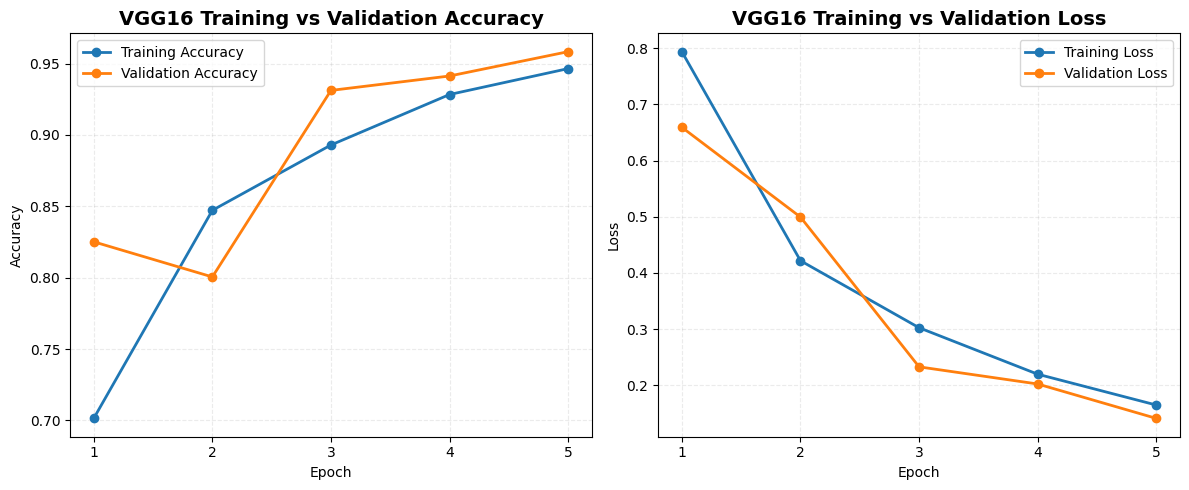

In [36]:
import matplotlib.pyplot as plt

# ============================================
# VGG16 TRAINING HISTORY
# ============================================

plt.figure(figsize=(12, 5))

# --------------------------------------------
# Accuracy
# --------------------------------------------

plt.subplot(1, 2, 1)

plt.plot(
    history_vgg.history["accuracy"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history_vgg.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title(
    "VGG16 Training vs Validation Accuracy",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.xticks(
    range(len(history_vgg.history["accuracy"])),
    range(1, len(history_vgg.history["accuracy"]) + 1)
)

plt.legend()
plt.grid(
    linestyle="--",
    alpha=0.25
)


# --------------------------------------------
# Loss
# --------------------------------------------

plt.subplot(1, 2, 2)

plt.plot(
    history_vgg.history["loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history_vgg.history["val_loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.title(
    "VGG16 Training vs Validation Loss",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(
    range(len(history_vgg.history["loss"])),
    range(1, len(history_vgg.history["loss"]) + 1)
)

plt.legend()
plt.grid(
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

## checking accuracy for test dataset

In [38]:
vgg_test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

vgg_test_ds = vgg_test_ds.map(
    preprocess_vgg16_validation,
    num_parallel_calls=tf.data.AUTOTUNE
)

vgg_test_ds = vgg_test_ds.batch(BATCH_SIZE)
vgg_test_ds = vgg_test_ds.prefetch(tf.data.AUTOTUNE)

test_loss, test_accuracy = vgg16_model.evaluate(
    vgg_test_ds,
    verbose=1
)

print("=" * 50)
print("VGG16 TEST RESULTS")
print("=" * 50)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

print("=" * 50)

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 294ms/step - accuracy: 0.9533 - loss: 0.1533
VGG16 TEST RESULTS
Test Loss     : 0.1533
Test Accuracy : 95.33%


## classification report

In [39]:
import numpy as np

y_true = []
y_pred = []

for images, labels in vgg_test_ds:

    predictions = vgg16_model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())
    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully.")

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

Predictions generated successfully.
              precision    recall  f1-score   support

      glioma     0.9710    0.9520    0.9614       563
  meningioma     0.9320    0.8949    0.9130       352
    no_tumor     0.9314    0.9810    0.9556       263
   pituitary     0.9616    0.9877    0.9745       406

    accuracy                         0.9533      1584
   macro avg     0.9490    0.9539    0.9511      1584
weighted avg     0.9534    0.9533    0.9530      1584



## confusion matrix

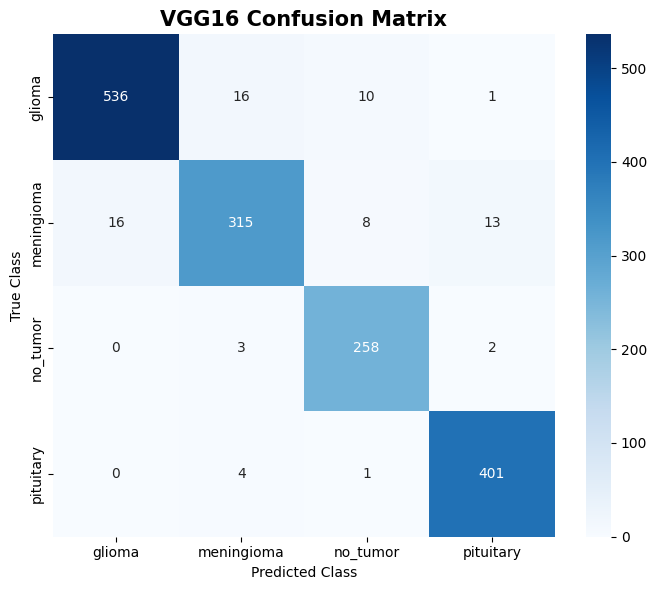

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "VGG16 Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

In [41]:
# Save trained VGG16 model
vgg16_model.save("VGG_16_brain_tumor.keras")

print("Model saved successfully as VGG_16_brain_tumor.keras")

Model saved successfully as VGG_16_brain_tumor.keras


In [42]:
from google.colab import files

files.download("VGG_16_brain_tumor.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **CNN Model**

In [ ]:
import tensorflow as tf

BATCH_SIZE = 32

# ============================================
# CUSTOM CNN PREPROCESSING
# ============================================

def preprocess_custom_cnn(image_path, label):

    # 1. Convert to grayscale
    image = convert_to_grayscale(image_path)

    # 2. Resize to 224 × 224
    image = resize_image(image)

    # 3. Normalize to [0, 1]
    image = normalize_image(image)

    return image, label


# ============================================
# TRAINING + AUGMENTATION
# ============================================

def preprocess_custom_cnn_train(image_path, label):

    image, label = preprocess_custom_cnn(
        image_path,
        label
    )

    # Augmentation only for training
    image = data_augmentation(
        image,
        training=True
    )

    return image, label


# ============================================
# TRAIN DATASET
# ============================================

custom_train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

custom_train_ds = custom_train_ds.shuffle(
    buffer_size=len(train_paths),
    seed=42
)

custom_train_ds = custom_train_ds.map(
    preprocess_custom_cnn_train,
    num_parallel_calls=tf.data.AUTOTUNE
)

custom_train_ds = custom_train_ds.batch(
    BATCH_SIZE
)

custom_train_ds = custom_train_ds.prefetch(
    tf.data.AUTOTUNE
)


# ============================================
# VALIDATION DATASET
# ============================================

custom_val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

custom_val_ds = custom_val_ds.map(
    preprocess_custom_cnn,
    num_parallel_calls=tf.data.AUTOTUNE
)

custom_val_ds = custom_val_ds.batch(
    BATCH_SIZE
)

custom_val_ds = custom_val_ds.prefetch(
    tf.data.AUTOTUNE
)


# ============================================
# VERIFY
# ============================================

for images, labels in custom_train_ds.take(1):

    print("=" * 50)
    print("CUSTOM CNN DATASET VERIFICATION")
    print("=" * 50)

    print("Image shape :", images.shape)
    print("Label shape :", labels.shape)
    print("Min pixel   :", tf.reduce_min(images).numpy())
    print("Max pixel   :", tf.reduce_max(images).numpy())

    print("=" * 50)

CUSTOM CNN DATASET VERIFICATION
Image shape : (32, 224, 224, 1)
Label shape : (32,)
Min pixel   : 0.0
Max pixel   : 0.99679923


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = 4

custom_cnn = models.Sequential([

    layers.Input(shape=(224, 224, 1)),

    # ==========================================
    # BLOCK 1
    # ==========================================
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # ==========================================
    # BLOCK 2
    # ==========================================
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # ==========================================
    # BLOCK 3
    # ==========================================
    layers.Conv2D(
        128, (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.Conv2D(
        128, (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # ==========================================
    # BLOCK 4
    # ==========================================
    layers.Conv2D(
        256, (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.Conv2D(
        256, (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # ==========================================
    # CLASSIFICATION HEAD
    # ==========================================
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.Dropout(0.5),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

custom_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             

 Total params: 1,273,828 (4.86 MB)

 Trainable params: 1,272,356 (4.85 MB)

 Non-trainable params: 1,472 (5.75 KB)

## compile

In [ ]:
custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_custom = custom_cnn.fit(
    custom_train_ds,
    validation_data=custom_val_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 167s 668ms/step - accuracy: 0.5855 - loss: 1.0805 - val_accuracy: 0.4375 - val_loss: 2.9114 - learning_rate: 0.0010
Epoch 2/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.6619 - loss: 0.8564
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
231/231 ━━━━━━━━━━━━━━━━━━━━ 129s 557ms/step - accuracy: 0.6769 - loss: 0.8175 - val_accuracy: 0.3561 - val_loss: 4.2908 - learning_rate: 0.0010
Epoch 3/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 123s 534ms/step - accuracy: 0.7688 - loss: 0.5945 - val_accuracy: 0.6446 - val_loss: 1.4373 - learning_rate: 5.0000e-04
Epoch 4/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.7907 - loss: 0.5422
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
231/231 ━━━━━━━━━━━━━━━━━━━━ 129s 558ms/step - accuracy: 0.8018 - loss: 0.5078 - val_accuracy: 0.5505 - val_loss: 1.5189 - learning_rate: 5.0000e-04
Epoch 5/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 143s 562ms/step - accuracy: